# Homework 3: Survival Analysis

This notebook runs the full implementation for the Telco survival-analysis homework:

1. build parametric AFT models,
2. compare the distributions,
3. visualize all survival curves in one plot,
4. select statistically significant features,
5. keep the final model,
6. calculate CLV per customer,
7. explore CLV by segments,
8. estimate a retention budget and summarize findings.


In [48]:
import pandas as pd
from IPython.display import display, Markdown, Image

## Run the full analysis

In [49]:
!python3 homework3_survival.py --data data/telco.csv --output-dir outputs

Done. Outputs saved to: outputs


## Model comparison

In [50]:
comparison = pd.read_csv("outputs/model_comparison_with_final.csv")
display(comparison)

,model,log_likelihood,n_params,AIC,BIC,converged
0,final_lognormal_significant_features,-1462.100331,10,2944.200663,2993.278216,True
1,lognormal,-1457.012005,20,2954.024010,3052.179116,True
2,loglogistic,-1458.103079,20,2956.206157,3054.361263,True
3,weibull,-1462.171624,20,2964.343249,3062.498354,True
4,exponential,-1467.597507,19,2973.195014,3066.442364,True


## Final model coefficients

In [51]:
coef = pd.read_csv("outputs/final_model_coefficients.csv")
display(coef)

,term,coef,se,z,p_value,time_ratio
0,Intercept,4.564606,0.148228,30.794513,3.103402e-208,96.024774
1,age_z,0.462265,0.080331,5.754538,8.687903e-09,1.587667
2,address_z,0.431735,0.089196,4.840310,1.296371e-06,1.539927
3,marital_Unmarried,-0.447332,0.114472,-3.907803,9.313939e-05,0.639332
4,voice_Yes,-0.463513,0.166770,-2.779354,5.446718e-03,0.629070
5,internet_Yes,-0.840546,0.138259,-6.079516,1.205459e-09,0.431475
6,custcat_E-service,1.025820,0.169046,6.068298,1.292725e-09,2.789381
7,custcat_Plus service,0.822526,0.169424,4.854840,1.204837e-06,2.276243
8,custcat_Total service,1.013283,0.209578,4.834877,1.332280e-06,2.754630
9,log_sigma,0.283027,0.046020,6.150149,7.740998e-10,1.327141


## Survival curves for all AFT distributions

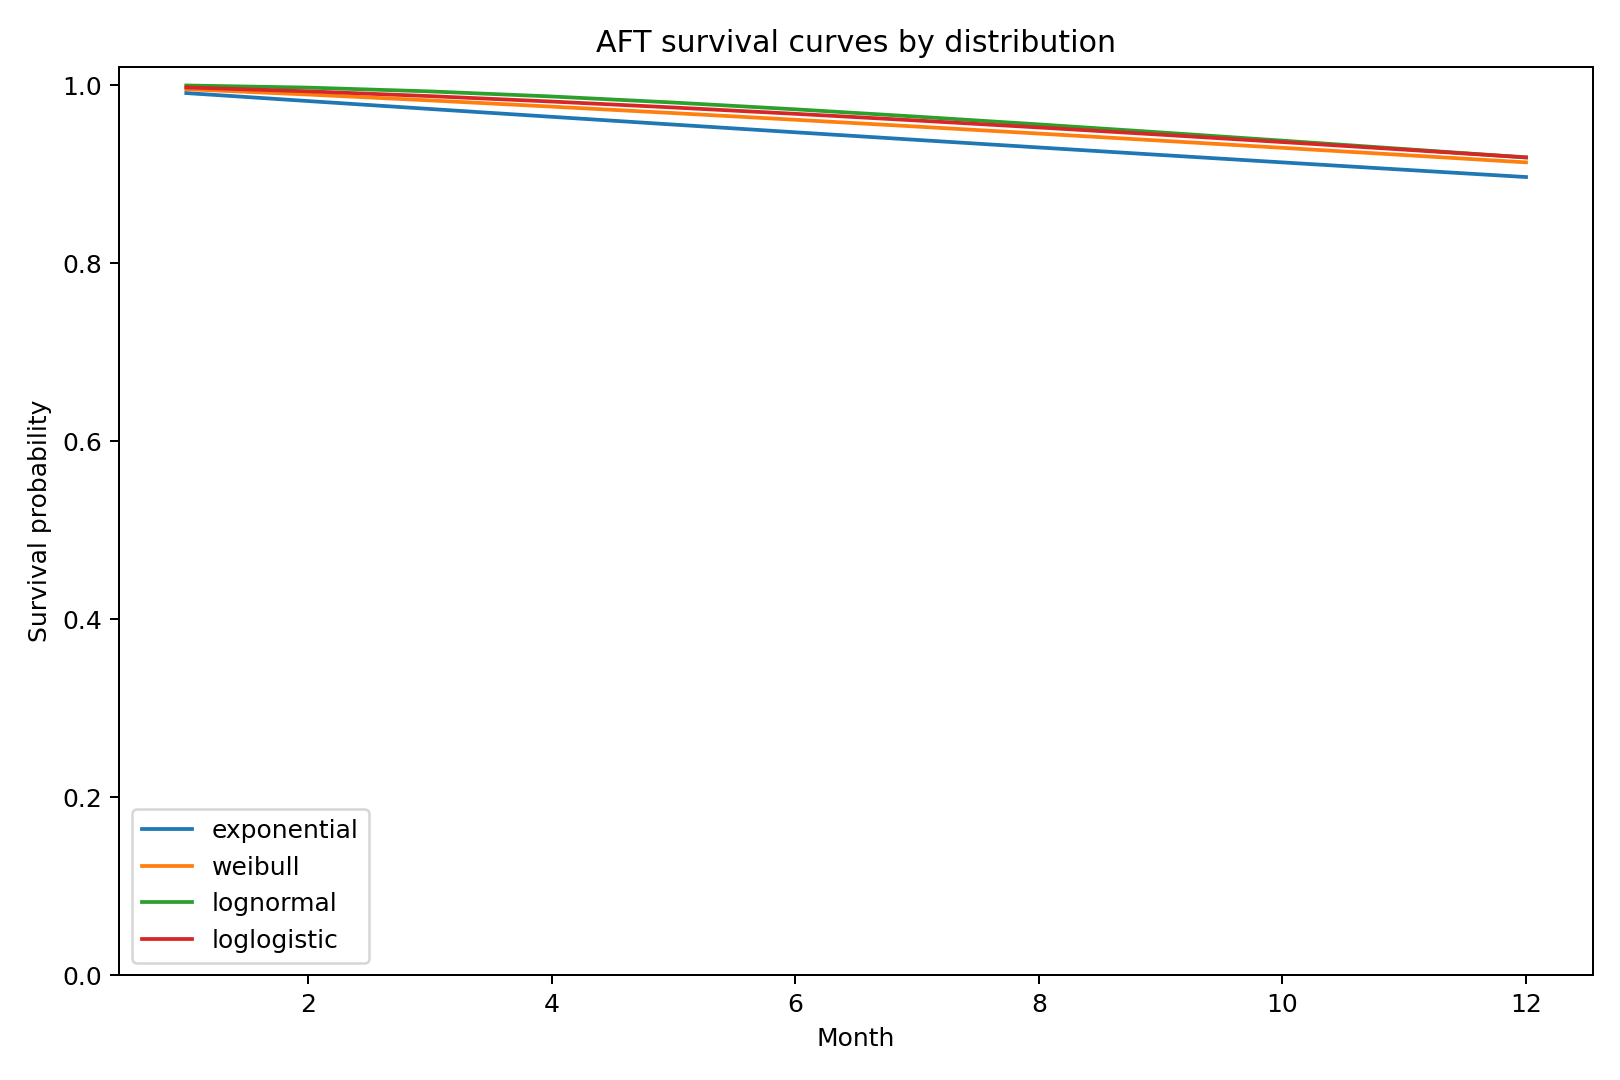

In [52]:
Image("outputs/plots/aft_survival_curves_all_models.png")

## CLV per customer

In [53]:
clv = pd.read_csv("outputs/clv_per_customer.csv")
display(clv[["ID", "tenure", "churn", "survival_12m", "churn_risk_12m", "CLV_12m_AMD", "at_risk_12m"]].head())
display(clv[["survival_12m", "churn_risk_12m", "CLV_12m_AMD"]].describe())

,ID,tenure,churn,survival_12m,churn_risk_12m,CLV_12m_AMD,at_risk_12m
0,1,13,Yes,0.939310,0.060690,14540.703088,False
1,2,11,Yes,0.944474,0.055526,14575.300888,False
2,3,68,No,0.997978,0.002022,14900.516260,False
3,4,33,Yes,0.842192,0.157808,13826.115804,False
4,5,23,No,0.962486,0.037514,14692.498823,False


,survival_12m,churn_risk_12m,CLV_12m_AMD
count,1000.000000,1000.000000,1000.000000
mean,0.889435,0.110565,14099.135350
std,0.123588,0.123588,1048.662328
min,0.243597,0.000016,7012.456450
25%,0.828995,0.015962,13720.865023
50%,0.935474,0.064526,14514.747747
75%,0.984038,0.171005,14823.956304
max,0.999984,0.756403,14910.020790


## CLV distribution

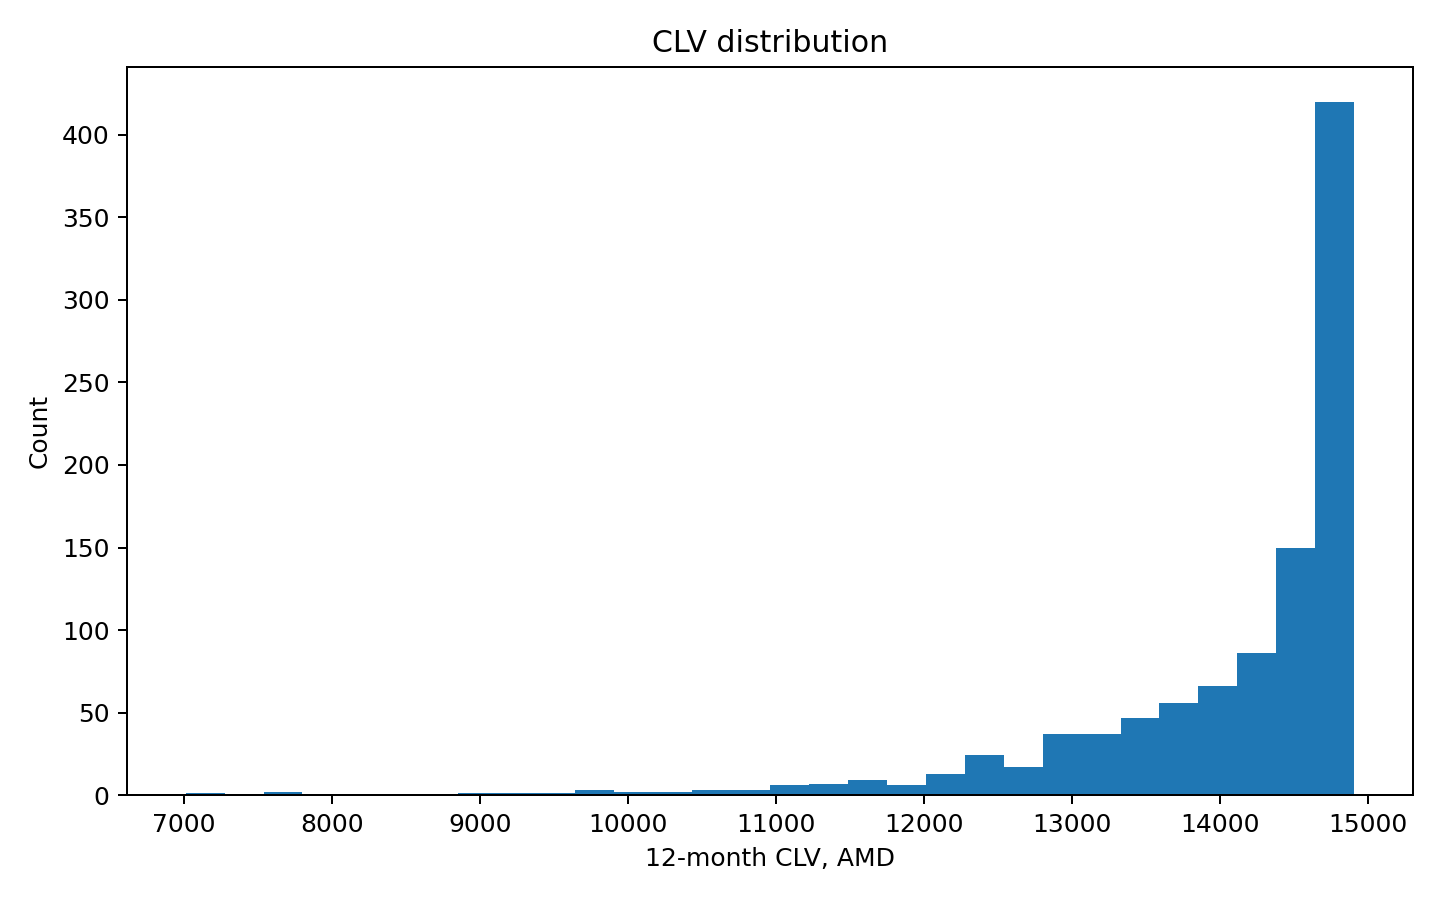

In [54]:
Image("outputs/plots/clv_distribution.png")

## CLV by customer category

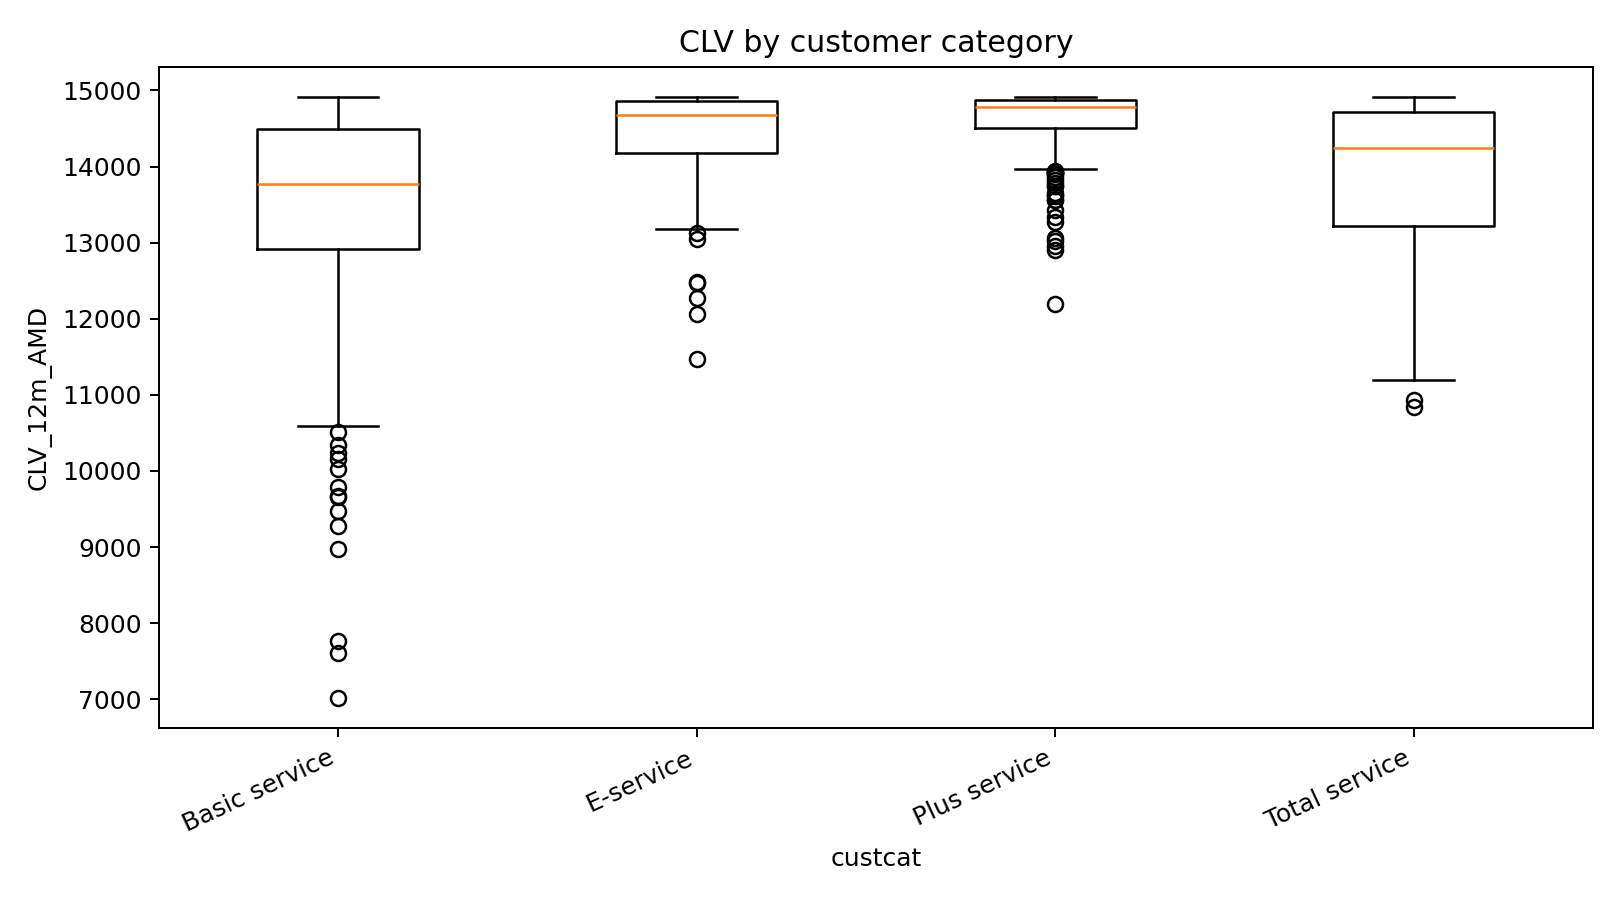

In [55]:
Image("outputs/plots/clv_by_custcat.png")

## Segment summary

In [56]:
segments = pd.read_csv("outputs/segment_summary.csv")
display(segments.sort_values("mean_CLV_12m_AMD", ascending=False).head(20))

,segment,level,n,observed_churn_rate,mean_CLV_12m_AMD,median_CLV_12m_AMD,mean_survival_12m,mean_churn_risk_12m,at_risk_count
21,retire,Yes,47,0.063830,14852.628933,14897.695393,0.989818,0.010182,0
2,custcat,Plus service,281,0.156584,14608.914116,14777.004287,0.953524,0.046476,4
1,custcat,E-service,217,0.271889,14447.797279,14678.521073,0.931603,0.068397,6
16,ed,Did not complete high school,204,0.156863,14443.353414,14759.449677,0.932970,0.067030,11
4,internet,No,632,0.181962,14438.125741,14712.348577,0.931020,0.068980,31
6,marital,Married,495,0.256566,14347.201458,14656.723958,0.919314,0.080686,36
13,voice,No,696,0.227011,14231.475826,14607.290029,0.905591,0.094409,71
17,ed,High school degree,287,0.219512,14160.947793,14640.299795,0.898218,0.101782,36
11,region,Zone 2,334,0.281437,14157.106517,14550.883327,0.896453,0.103547,32
10,region,Zone 1,322,0.279503,14110.016742,14490.436057,0.890624,0.109376,48


## Annual retention budget

In [57]:
budget = pd.read_csv("outputs/annual_retention_budget.csv")
display(budget)

,at_risk_threshold_churn_probability,at_risk_subscribers,expected_churners_12m_all_customers,expected_churners_12m_at_risk_group,sum_CLV_at_risk_group_AMD,suggested_upper_bound_retention_budget_AMD
0,0.25,135,110.565207,48.309768,1.617410e+06,562711.179774


## Report

In [58]:
display(Markdown(open("outputs/report.md", encoding="utf-8").read()))

# Homework 3: Survival Analysis Report

The final decision model is the reduced **lognormal AFT model**, which had the lowest AIC after comparing the full AFT distributions and refitting statistically significant predictors (`outputs/model_comparison_with_final.csv`). In an AFT model, positive coefficients increase expected survival time and lower churn risk, while negative coefficients shorten expected survival time and raise churn risk. The main risk-increasing factors are `internet_Yes` (time ratio 0.43), `voice_Yes` (time ratio 0.63), `marital_Unmarried` (time ratio 0.64); the main protective factors are `custcat_E-service` (time ratio 2.79), `custcat_Total service` (time ratio 2.75), `custcat_Plus service` (time ratio 2.28), `age_z` (time ratio 1.59), `address_z` (time ratio 1.54). This means internet service, voice service, and being unmarried are associated with earlier churn, while older age, longer address history, and higher-service customer categories are associated with longer expected survival (`outputs/final_model_coefficients.csv`).

I define a valuable segment as one with high 12-month CLV and high 12-month survival probability, because it combines future margin with realistic retention potential. By this definition, the strongest customer-category segments are **Plus service and E-service**, while **Basic service** has the highest average one-year churn risk and needs more retention attention (`outputs/segment_summary.csv`, `outputs/clv_per_customer.csv`). Assuming the data represents the full population, and defining at-risk subscribers as those with predicted 12-month churn probability above 25%, there are **135** at-risk subscribers with **48.31** expected churners within a year. I would set the annual retention budget at about **562,711 AMD**, calculated as at-risk CLV weighted by 12-month churn risk (`outputs/annual_retention_budget.csv`). For retention, I would prioritize high-CLV at-risk customers with internet or voice service, especially unmarried Basic or Total service customers, then use cheaper actions for lower-value risks: service-quality check-ins, plan education, bundle fixes, and controlled offer tests before scaling incentives.
